## Callibration with token-wise aggregation approach

### Imports

In [1]:
from transformers import AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm
from torch.utils.data import Dataset

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

import torch
import sys

sys.path.append("../services/")
from index import Index

/home/nikita/proga/Diplom/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def retrieve_answer_token_index(tokens):
    for i in range(len(tokens) - 1, 0, -1):
        if tokens[i]["token"].isdigit():
            return i


def retrieve_reasoning_tokens_range(tokens):
    field1_text = '"short_chain_of_thoughts": "'
    field2_text = '"answer": "'

    start_index, end_index = -1, -1

    tmp_text = ""
    for i in range(len(tokens)):
        if field1_text in tmp_text:
            start_index = i
            break
        tmp_text += tokens[i]["token"]

    tmp_text = ""

    for i in range(len(tokens) - 1, 0, -1):
        tmp_text = tokens[i]["token"] + tmp_text
        if field2_text in tmp_text:
            end_index = i
            break

    return (start_index, end_index)

### Preparation

In [3]:
torch.random.manual_seed(42)

dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test").select(range(5000))
index = Index("../index_data/qwen2.5-7B_launch5000")
model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

In [ ]:
PAD_VAL = 0

VOCAB_SIZE = 20
split_val = len(index) // 2


class IndexDataset(Dataset):
    def __init__(
        self,
        index,
        dataset,
        split="train",
        device=torch.device("cpu"),
    ):
        self.index = index
        self.dataset = dataset
        self.split = split
        self.device = device

        if split == "train":
            self.indices = list(range(int(len(index) * 0.6)))
        elif split == "val":
            self.indices = list(range(int(len(index) * 0.6), int(len(index) * 0.8)))
        elif split == "test":
            self.indices = list(range(int(len(index) * 0.8), len(index)))

    def __len__(self):
        return len(self.indices) - 1

    def get(self, start=0, end=-1):
        xs = np.array(
            [
                x
                for x in self.index.load_data_generator(
                    self.indices[start], self.indices[end]
                )
            ]
        )
        ys = np.array(
            self.dataset.select(range(self.indices[start], self.indices[end]))
        )

        allowed_ids = []
        for i, x in enumerate(xs):
            # Ignoring responses where answer token distribution doesn't have all 0-9 tokens
            log = x["logprobs"][retrieve_answer_token_index(x["logprobs"])]
            if (
                len(
                    set([str(x) for x in range(10)]).intersection(
                        set([x["token"] for x in log["top_logprobs"]])
                    )
                )
                < 10
            ):
                continue
            allowed_ids.append(i)

        return self.process_elements(xs[allowed_ids], ys[allowed_ids])

    def process_elements(self, xs, ys):
        processed = {}

        answer_logits = torch.zeros((len(xs), VOCAB_SIZE))
        reasoning_logits = []

        targets = torch.zeros(len(ys), dtype=torch.long)

        for i, (x, y) in enumerate(zip(xs, ys)):
            # Reasoning tokens processing
            reasoning_tokens_indices = retrieve_reasoning_tokens_range(
                x["logprobs"]
            )
            reasoning_tokens_top_logprobs = []
            for j in reasoning_tokens_indices:
                reasoning_tokens_top_logprobs.append(
                    [v["logprob"] for v in x["logprobs"][j]["top_logprobs"]]
                )

            max_reasoning_logprobs, _ = torch.max(
                torch.tensor(reasoning_tokens_top_logprobs), dim=1
            )
            norm_reasoning_top_logprobs = (
                torch.tensor(reasoning_tokens_top_logprobs).sub(max_reasoning_logprobs.unsqueeze(-1))
            )
            reasoning_logits.append(norm_reasoning_top_logprobs)

            # Answer tokens processing
            answer_token_index = retrieve_answer_token_index(x["logprobs"])
            answer_top_logprobs_tokens = [
                v["token"]
                for v in x["logprobs"][answer_token_index]["top_logprobs"]
            ]
            answer_top_logprobs = torch.tensor(
                [
                    v["logprob"]
                    for v in x["logprobs"][answer_token_index]["top_logprobs"]
                ]
            )

            max_answer_logprob = answer_top_logprobs.max()
            norm_answer_top_logprobs = answer_top_logprobs - max_answer_logprob
            answer_logits[i] = norm_answer_top_logprobs

            targets[i] = torch.tensor(
                answer_top_logprobs_tokens.index(str(y["answer_index"])),
                dtype=torch.long,
            )

        processed["answer_logits"] = answer_logits
        processed["reasoning_logits"] = torch.cat(reasoning_logits)
        processed["targets"] = targets

        return processed

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = IndexDataset(
    index, dataset, split="train", device=device
)
val = IndexDataset(
    index, dataset, split="val", device=device
)
test = IndexDataset(
    index, dataset, split="test", device=device
)


In [6]:
val_data = val.get()
test_data = test.get()

### Function to measure ECE

In [7]:
def calculate_ece_adaptive_bins(confidences, accuracies, n_bins=10, verbose=False):
    sorted_indices = torch.argsort(confidences)
    sorted_probs = confidences[sorted_indices]
    sorted_accuracies = accuracies[sorted_indices]
    
    n_samples = len(sorted_probs)
    bin_size = n_samples // n_bins
    
    ece = torch.zeros(1).to(device)
    
    if verbose:
        bin_avg_confidences = []
        bin_accuracies_list = []
        bin_conf_min = []
        bin_conf_max = []
        
    for i in range(n_bins):
        start_idx = i * bin_size
        if i == n_bins - 1:
            end_idx = n_samples
        else:
            end_idx = (i + 1) * bin_size
            
        if end_idx > start_idx:
            bin_probs = sorted_probs[start_idx:end_idx]
            bin_accuracies = sorted_accuracies[start_idx:end_idx]
            
            prop_in_bin = (end_idx - start_idx) / n_samples
            
            if prop_in_bin > 0:
                accuracy_in_bin = bin_accuracies.float().mean()
                avg_confidence_in_bin = bin_probs.mean()
                ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
                
            if verbose:
                bin_avg_confidences.append(avg_confidence_in_bin.detach().cpu())
                bin_accuracies_list.append(accuracy_in_bin.detach().cpu())
                bin_conf_min.append(bin_probs.min().detach().cpu())
                bin_conf_max.append(bin_probs.max().detach().cpu())
                    
    if verbose:
        bin_avg_confidences = torch.stack(bin_avg_confidences).numpy()
        bin_accuracies_list = torch.stack(bin_accuracies_list).numpy()
        bin_conf_min = torch.stack(bin_conf_min).numpy()
        bin_conf_max = torch.stack(bin_conf_max).numpy()

        plt.figure(figsize=(6, 6))

        # Perfect calibration
        plt.plot(
            [0, 1], [0, 1],
            linestyle="--",
            color="gray",
            label="Perfect calibration"
        )

        # Reliability curve (points)
        plt.plot(
            bin_avg_confidences,
            bin_accuracies_list,
            marker="o",
            linewidth=2,
            label="Model (adaptive bins)"
        )

        # Shaded bin coverage
        for i in range(len(bin_accuracies_list)):
            plt.fill_between(
                [bin_conf_min[i] if i > 0 else 0, bin_conf_max[i] if i < len(bin_accuracies_list) - 1 else 1],
                0,
                bin_accuracies_list[i] + 0.005,
                alpha=0.4
            )

        plt.xlabel("Confidence")
        plt.ylabel("Accuracy")
        plt.title("Reliability Diagram with Adaptive Bin Coverage")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return ece.item()

### Aggregations collecting

In [8]:
reasoning_tokens_probs = []

for i in range(len(test_data["reasoning_logits"])):
    reasoning_tokens_probs.append(torch.softmax(test_data["reasoning_logits"][i], dim=0)[0])
answer_tokens_probs = torch.softmax(test_data["answer_logits"], dim=0)[0]

/tmp/ipykernel_54271/1213677076.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  accuracies = torch.tensor(accuracies)


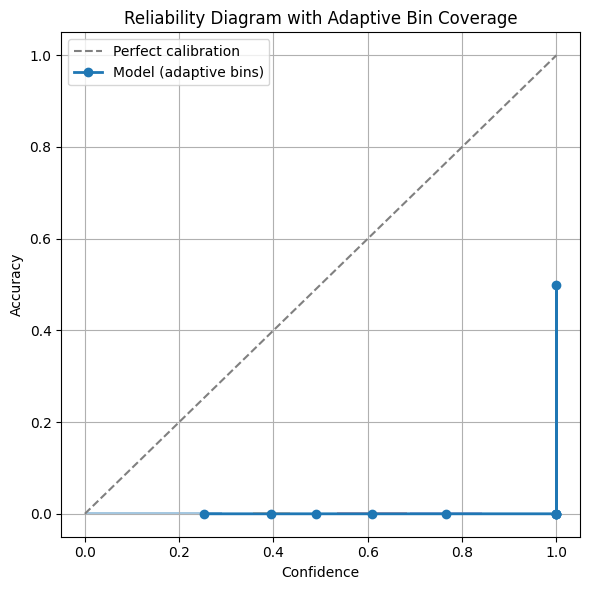

ECE: 0.7012228965759277


In [9]:

# Mean

confidences = []
accuracies = []

for i in range(len(answer_tokens_probs)):
    confidences.append(torch.mean(reasoning_tokens_probs[i] + answer_tokens_probs[i]))
accuracies = torch.argmax(test_data["answer_logits"], dim=1) == test_data["targets"]
    
confidences = torch.tensor(confidences)
accuracies = torch.tensor(accuracies)

print(f"ECE: {calculate_ece_adaptive_bins(confidences, accuracies, verbose=True)}")

### Results